# Quality of asymptotic approximation for Wald test statistic for SVD
This notebook contains replication files for the figures relating to the Wald test statistic for inference on singular subspaces.

In [5]:
using Distributions, Statistics, LinearAlgebra, StatsPlots
pgfplotsx()

Plots.PGFPlotsXBackend()

In [6]:
ms=2
n=5
m = 3
M2 = [[rand(1:ms*n) for i in 1:ms, j in 1:n]; zeros(1,n)]
F = 2
mu = zeros(m)
cov = [ 1 2 4 ; 2 3 3.5; 2 5 7];
c = cov * cov' / 100;
d = MvNormal(mu,c);
mc_reps = 2000;
sample_size = 500;
q = 1;
rand(d,n)

3×5 Matrix{Float64}:
 0.0893464  -0.785961  0.405185  -0.476203  0.198289
 0.0854878  -0.729996  0.264834  -0.552731  0.324802
 0.143073   -1.29819   0.648194  -0.93595   0.395424

In [7]:
ms=2
n=5
m = 3
M2 = [[rand(1:ms*n) for i in 1:ms, j in 1:n]; zeros(1,n)]
F = 2
mu = zeros(m)
cov = [ 1 2 4 ; 2 3 3.5; 2 5 7];
c = cov * cov' / 100;
d = MvNormal(mu,c);
mc_reps = 2000;
sample_size = 500;
q = 1;
f = q;

#first dimension of errors is mc_reps and second dimension is sample
errors = [M2 + rand(d,n) for _ in 1:mc_reps, _ in 1:sample_size];
#makes a mc_reps by 1 matrix of matrices
matrix_estimates = mean(errors,dims=(2));

demeaned_matrices = [errors[i,:,:] .- matrix_estimates[i,:,:] for i in 1:mc_reps]

cov_estimates = Array{Float64,3}(undef,mc_reps,m*n,m*n) 
smaller_cov_estimate = Array{Float64}(undef,m,m);
smaller_cov_estimates = Array{Float64,3}(undef,mc_reps,m,m)

for mcrep in 1:mc_reps
    cov_estimate = Array{Float64,2}(undef,m*n,m*n);
    fill!(cov_estimate,0.0);
    for s in 1:sample_size
        cov_estimate += vec(demeaned_matrices[mcrep][s])*vec(demeaned_matrices[mcrep][s])';
    end
    #average across other dimension
    fill!(smaller_cov_estimate,0.0)
    for maus in 1:n
        #1 p+1 2p+1 to p 2p 
        smaller_cov_estimate += cov_estimate[(1+ (maus-1)*m) : (maus*m) , (1+ (maus-1)*m) : (maus*m) ]
    end

    cov_estimates[mcrep,:,:] = cov_estimate / sample_size;
    smaller_cov_estimates[mcrep,:,:] = smaller_cov_estimate / (n*sample_size)
end


Now, we have made errors, find a matrix

In [8]:
F = svd(M2)
Us = F.U[:,1:q];
Usperp = nullspace(Us')
Usperp'Us
Us'Us

1×1 Matrix{Float64}:
 1.0000000000000002

Make a null DGP

In [9]:
F=2;
Fac=svd(M2)
Us = Fac.U[:,1:F];
Σs = Diagonal(Fac.S[1:F])
Vsp = Fac.Vt[1:F,:]
round.(M2 - Us * Σs * Vsp) .== 0
Un = Fac.U[:,(F+1):m]
Σn = Fac.S[F+1:m] |> Diagonal
Vn = Fac.Vt[F+1:m,:]
Df = zeros(F,F);
#singular vector of interest f = 1
u0f_perp = nullspace(Us[:,f]')[:,1]

3-element Vector{Float64}:
 -0.6873632980297875
  0.7263137727742834
  0.0

Check that an estimated SVD works roughly.

In [10]:
svd(matrix_estimates[1])

SVD{Float64, Float64, Matrix{Float64}, Vector{Float64}}
U factor:
3×3 Matrix{Float64}:
 -0.726691      0.686965    -0.000532207
 -0.686965     -0.72669      0.00116081
  0.000410686   0.00120916   0.999999
singular values:
3-element Vector{Float64}:
 17.128159603813533
  4.612548771388857
  0.05139910543484345
Vt factor:
3×5 Matrix{Float64}:
 -0.290689  -0.496206  -0.540331  -0.494573   -0.364307
  0.42978   -0.049461   0.403794  -0.0515733  -0.804446
 -0.677372   0.593055   0.232233  -0.255085   -0.26543

In [11]:
include("definitions_test_statistics.jl")
waldresult3 = [WaldStatSingleVector(u0f_perp,matrix_estimates[i],smaller_cov_estimates[i,:,:],f,F,sample_size) for i in 1:mc_reps];

Check that we don't need to impose the rank correctly, as specified in Liu and Ma (2007), i.e. it does not matter whether the constraint binds or not in $F \leq \min(n,m)$

In [12]:
include("definitions_test_statistics.jl")
waldresult4 = [WaldStatSingleVector(u0f_perp,matrix_estimates[i],smaller_cov_estimates[i,:,:],f,min(n,m),sample_size) for i in 1:mc_reps];

In [13]:
chsq = Chisq(1);
reference = [rand(chsq) for _ in 1:mc_reps];

## Correctly imposing reduced rank
The underlying perturbation theory builds on the null model that has a reduced rank which we impose during estimation. Assuming such reduced rank produces the following asymptotic approximation.

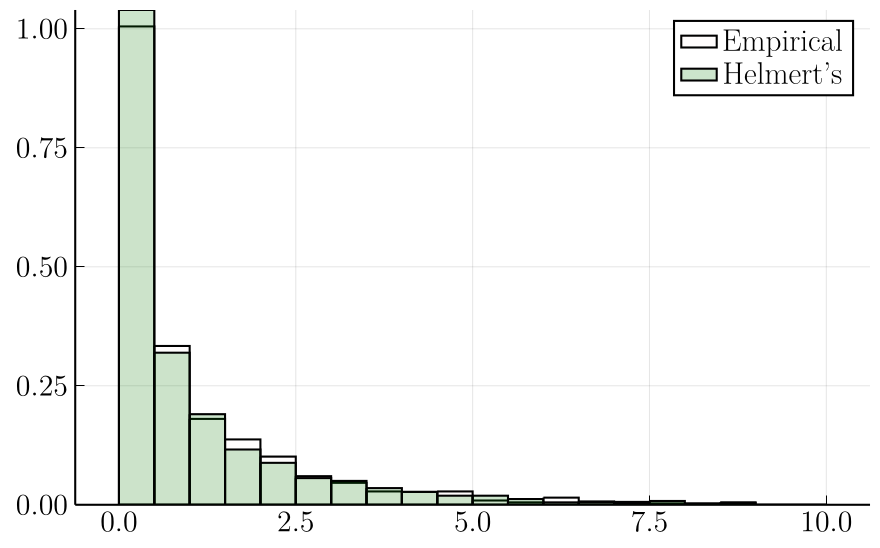

In [17]:
b_range = range(0, 10, length=21)
histogram([waldresult3 reference], label=["Empirical" "Helmert's"],bins=b_range,
            normalize = :pdf, 
            color=[:red :green],
            fillalpha=[0.01 0.2],
            tickfontsize=15,
            labelfontsize = 15,
            legendfontsize = 15,
            legend = :topright)

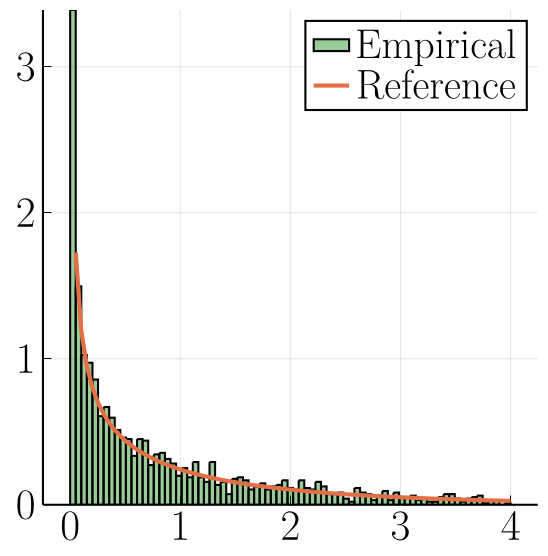

In [20]:
#import Pkg; Pkg.add("LaTeXStrings");
#using LaTeXStrings;
b_range2 = range(0, 4, length=80)
densplot=histogram(waldresult3, label="Empirical",bins=b_range2,normalize = :pdf, color=:green,fillalpha=0.4)
plot!(densplot,b_range2,Chisq(1),label="Reference",lw=2,
            tickfontsize=20,
            labelfontsize = 20,
            legendfontsize = 20,
            legend = :topright,
            size = (400,400)) #label=L"\chi^2_{1}"
densplot

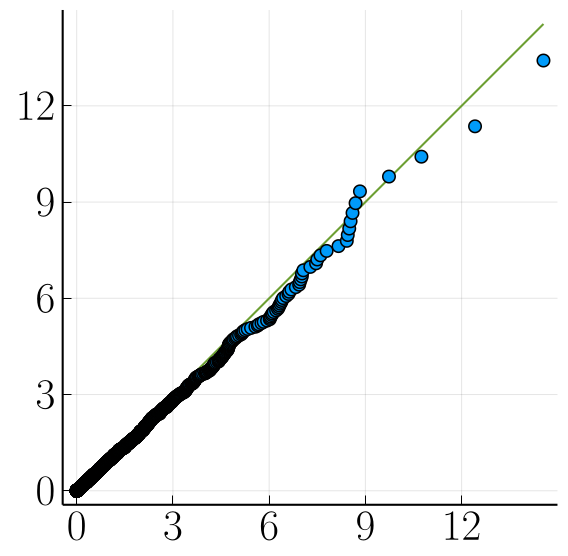

In [22]:
quant_plot = qqplot(waldresult3,Chisq(1),
            tickfontsize=20,
            labelfontsize = 20,
            legendfontsize = 20,
            size = (400,400))

## Incorrectly imposing full rank
We re-ran the experiment imposing full rank, which, as expected, does not change the underlying distribution.

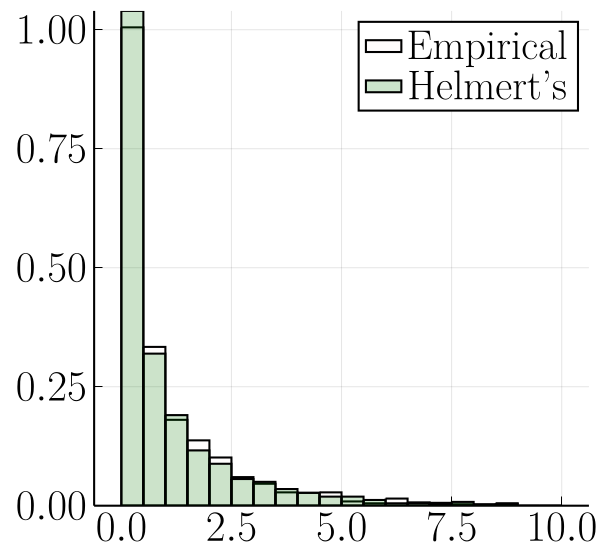

In [24]:
b_range = range(0, 10, length=21)
histogram([waldresult4 reference], label=["Empirical" "Helmert's"],bins=b_range,
                normalize = :pdf,
                color=[:red :green],fillalpha=[0.01 0.2],
                tickfontsize=20,
            labelfontsize = 20,
            legend = :topright,
            legendfontsize = 20,
            size = (400,400))

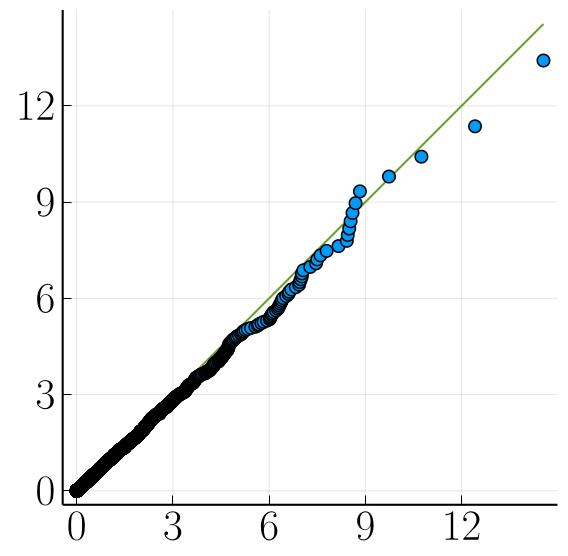

In [25]:
quant_plot_fullrank = qqplot(waldresult4,Chisq(1),
                                tickfontsize=20,
                                labelfontsize = 20,
                                legendfontsize = 20,
                                size = (400,400))

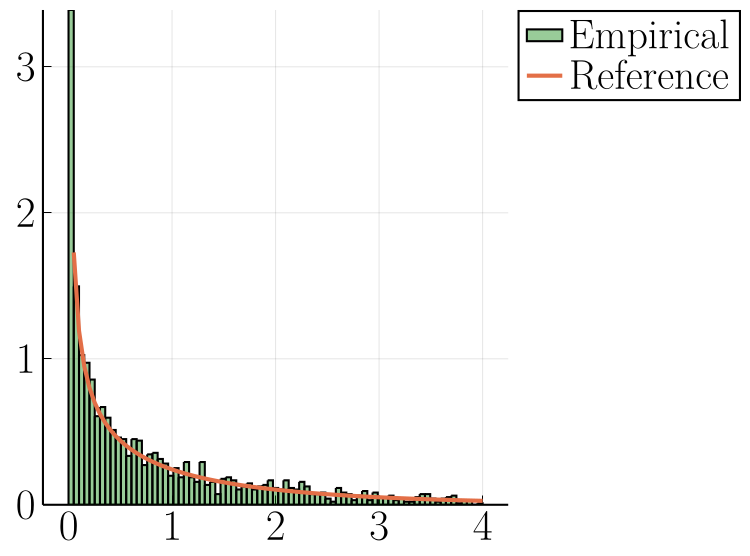

In [26]:
b_range2 = range(0, 4, length=80)
densplot_full_rank=histogram(waldresult4,
                                label="Empirical",bins=b_range2,
                                normalize = :pdf,
                                color=:green,tickfontsize=20,
                                labelfontsize = 20,
                                legendfontsize = 20,
                                size = (400,400),fillalpha=0.4)
plot!(densplot_full_rank,b_range2,Chisq(1),label="Reference",lw=2) #label=L"\chi^2_{1}"
densplot_full_rank

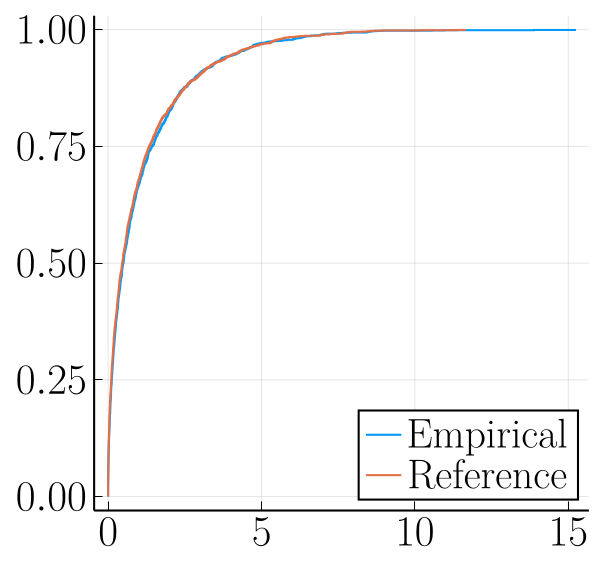

In [ ]:
using StatsBase
scatter(ecdf(waldresult3),label="Empirical",
                                tickfontsize=20,
                                labelfontsize = 20,
                                legendfontsize = 20,
                                size = (400,400))
scatter!(ecdf(reference),label="Reference",legend=:bottomright)

In [29]:
savefig("../output/plots/cdfwald-svd.svg")
png(densplot,"../output/plots/density_wald_svd")
savefig(quant_plot,"../output/plots/qqplot2_svd.svg")

"/Users/jerome/Documents/resolvent-note/output/plots/qqplot2_svd.svg"

## Empirical size
Estimate size using chi squared critical values

In [27]:
rejections = waldresult3 .> 3.841;
mean(rejections)

0.058